# IMPORT LIBRARIES

In [54]:
# PLOTTING & DATA STUFF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import joblib


# DIM REDUCTION
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from openTSNE import TSNE
from sklearn.manifold import Isomap
import umap

# OUTLIERS
from pyod.models.knn import KNN
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IsolationForest

# HELPERS
from utils import backup_dataframe, load_latest_backup


# LOAD CSV

In [4]:

pd.set_option('display.max_colwidth', None)  # Show full content in columns
pd.set_option('display.max_rows', None)

In [5]:
df = pd.read_csv("dataset/train_pre_outlier.csv")

# FAST CHECK AND PROCESS

In [6]:
df.shape

(130974, 71)

In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,runtimeMinutes,awardWins,numVotes,totalCredits,awardNominationsExcludeWins,canHaveEpisodes,isAdult,numRegions,...,genre_Romance,genre_Short,filtered_soundMixes,mix_Unknown,mix_dolby_digital,mix_mono,mix_other_mix,mix_silent,mix_stereo,mix_unknown
0,0,0,-0.500000,0.0,-0.175258,-0.208333,0.0,0,0,0.0,...,0,1,['Unknown'],1,0,0,0,0,0,0
1,1,1,-0.557692,0.0,-0.206186,-0.270833,0.0,0,0,0.0,...,0,0,['Unknown'],1,0,0,0,0,0,0
2,2,2,0.134615,0.0,0.298969,0.875000,0.0,0,0,0.0,...,0,0,['mono'],0,0,1,0,0,0,0
3,3,3,0.269231,0.0,-0.092784,-0.583333,0.0,0,0,0.0,...,0,0,['Unknown'],1,0,0,0,0,0,0
4,4,4,-0.211538,0.0,-0.144330,-0.562500,0.0,0,0,-1.0,...,0,0,['Unknown'],1,0,0,0,0,0,0


In [8]:
df = df.drop(columns = ["Unnamed: 0.1", "Unnamed: 0"])

In [9]:
df.shape

(130974, 69)

In [10]:
numerical_vars_to_check = [
    'runtimeMinutes', 'awardWins', 'numVotes', 'totalCredits',
    'awardNominationsExcludeWins',
    'numRegions', 'userReviewsTotal', 'castNumber', 'companiesNumber',
    'averageRating', 'externalLinks', 'writerCredits', 'directorsCredits',
    'quotesTotal', 'title_length', 'release_decade', 'num_genres',
    'num_regions', 'word_count', 'num_countries',
    'award_ratio', 'total_multimedia'
]


In [11]:
cat = list(set(df.columns)-set(numerical_vars_to_check))

In [12]:
df_num = df.drop(cat, axis=1)

In [13]:
X = df_num.values

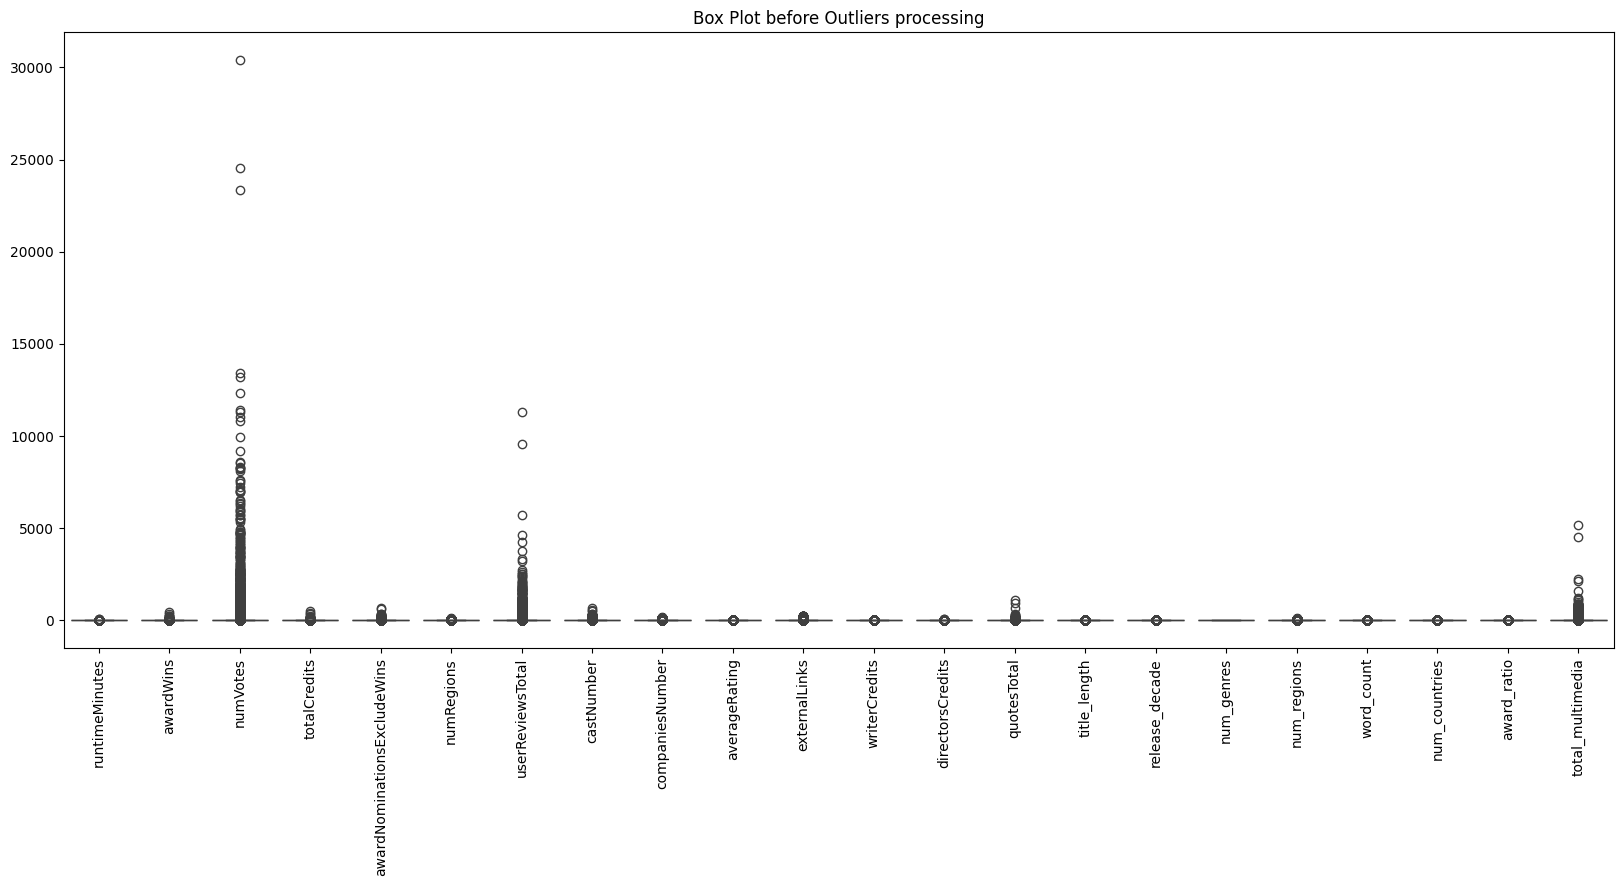

In [80]:
plt.figure(figsize=(20,8))
sns.boxplot(df_num)
plt.xticks(rotation=90)
plt.title("Box Plot before Outliers processing")
plt.show()

# DIM REDUCTION

## PCA

In [14]:
pca = PCA(n_components=2)  # Scegli il numero di componenti principali desiderate
X_pca = pca.fit_transform(X)


/var/folders/kz/z9pm_78940q0wmly2vd_r41h0000gn/T/ipykernel_65707/2686009907.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='muted', alpha=0.5,  s=5)
/var/folders/kz/z9pm_78940q0wmly2vd_r41h0000gn/T/ipykernel_65707/2686009907.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


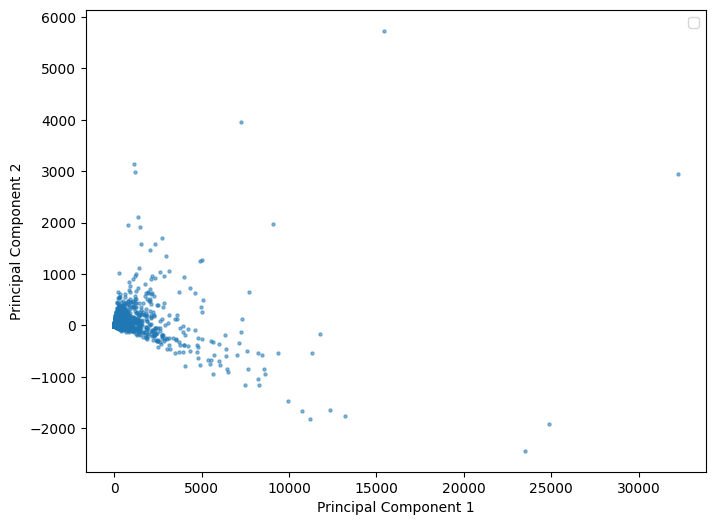

In [15]:
# Plot dei punti ridotti
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='muted', alpha=0.5,  s=5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [23]:

# Riduci la dimensionalità utilizzando PCA
pca = PCA(n_components=3)  # Scegli il numero di componenti principali desiderate
X_pca_3d = pca.fit_transform(X)

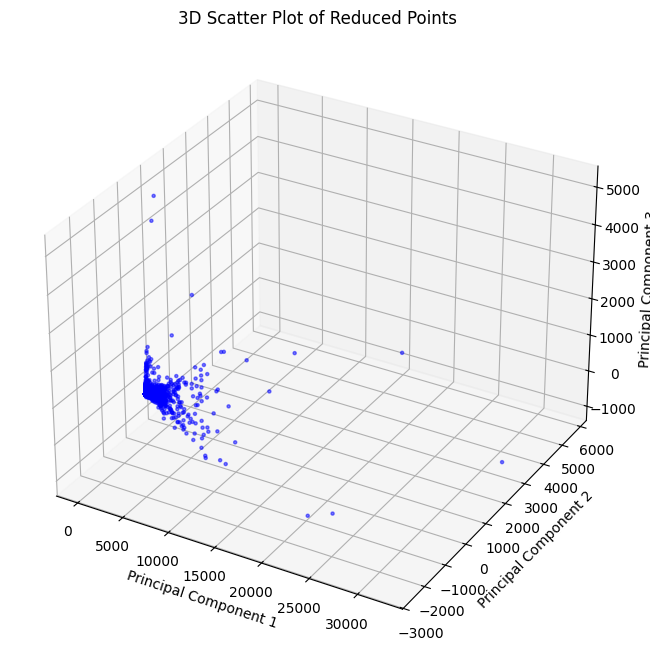

In [24]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c='blue', alpha=0.5, s=5)

# Add labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

plt.title('3D Scatter Plot of Reduced Points')
plt.show()

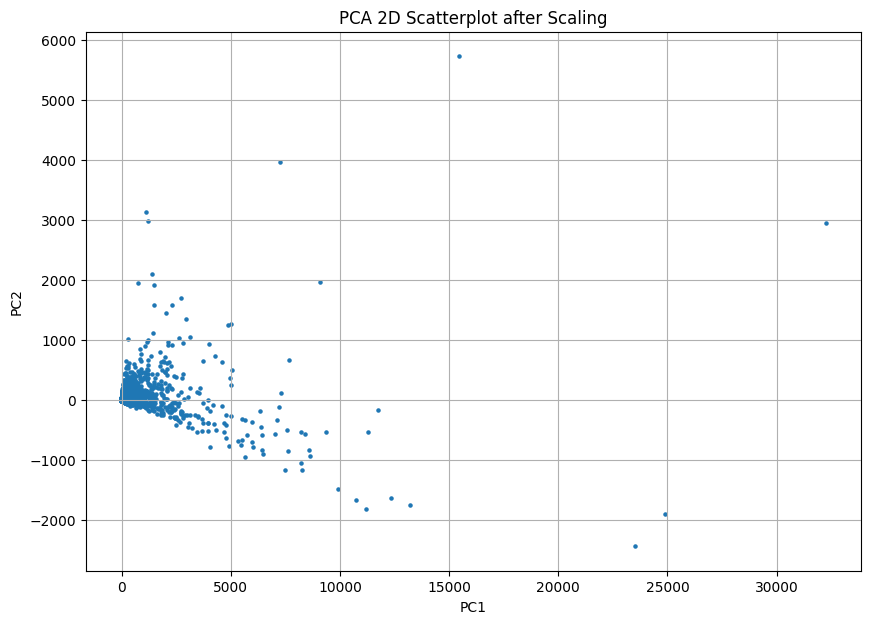

In [16]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Seleziona le variabili numeriche
X = df[numerical_vars_to_check]

# 2. Applica RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 3. Applica PCA sui dati scalati
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.title('PCA 2D Scatterplot after Scaling')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()


## T-SNE

In [20]:
#!pip install opentsne
#References: https://opentsne.readthedocs.io/en/stable/tsne_algorithm.html

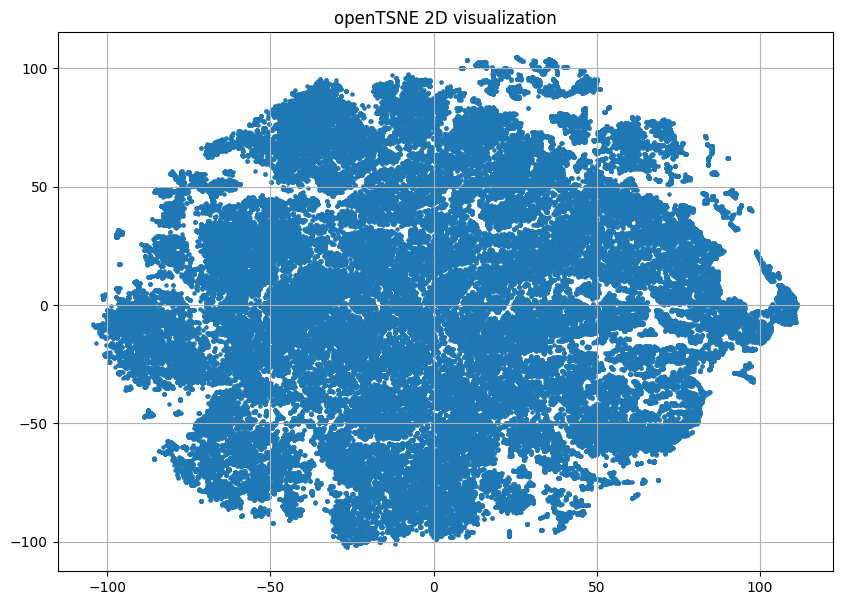

In [ ]:
"""
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization="pca",  # inizia con PCA embedding
    n_jobs=8,              # usa CPU parallele
    random_state=42
)

X_array = X.values  # <-- converti in array
X_embedded = tsne.fit(X_array)  # non direttamente X

plt.figure(figsize=(10, 7))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=5)
plt.title("openTSNE 2D visualization")
plt.grid(True)
plt.show()"""



In [ ]:
#np.save(file="arrays/X_embedded.npy", arr= X_embedded)

In [29]:
X_tsne = np.load("arrays/X_tsne.npy")

## UMAP

In [ ]:
#!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.0 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 10.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)

/Users/daviderizzello/Documents/UNIPI/Data_Mining/DataMining2/env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/daviderizzello/Documents/UNIPI/Data_Mining/DataMining2/env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [19]:
np.save("arrays/X_umap.npy", X_umap)

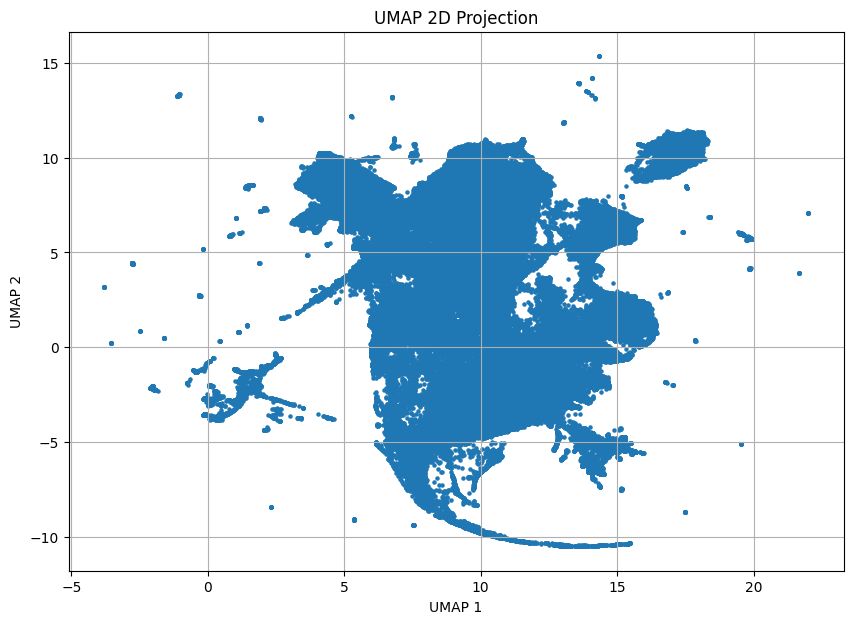

In [18]:

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5)
plt.title('UMAP 2D Projection')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

# DISTANCE BASED-APPROACH

In [ ]:
#!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.7/169.7 kB 3.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-2.0.4-py3-none-any.whl size=200480 sha256=58832b75470a89c58c527838e6f96a19557d0f44d0c8c7b883adfd51467dd241
  Stored in directory: /Users/daviderizzello/Library/Caches/pip/wheels/cb/54/28/d02f62720600bc815c41219efedd0cb86889737fb5ea3c8f9a
Successfully built pyod

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [22]:
%time
# 1. Fit di KNN sui dati scalati (non su umap!)
knn_detector = KNN(contamination=0.01, method='mean')  # 1% outlier
knn_detector.fit(X)




CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 8.82 μs


KNN(algorithm='auto', contamination=0.01, leaf_size=30, method='mean',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [23]:
# 2. Predizioni outlier
%time
outliers = knn_detector.predict(X)
np.unique(outliers, return_counts=True)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.81 μs


(array([0, 1]), array([129968,   1006]))

In [24]:
i= np.where(outliers == 1) # when comparing arrays of integers
i

(array([   307,    507,    540, ..., 130347, 130351, 130770], shape=(1006,)),)

In [ ]:
# Ottieni gli indici degli outlier
outlier_knn = np.where(outliers == 1)[0]

In [43]:
outliers_knn = knn_detector.labels_  # oppure se hai salvato predict

In [44]:
outlier_knn_indices = np.where(outliers_knn == 1)[0]

In [ ]:
np.save('arrays/outlier_indices_knn.npy', outlier_knn)

In [ ]:
outlier_indices = np.load('outlier_indices_knn.npy')

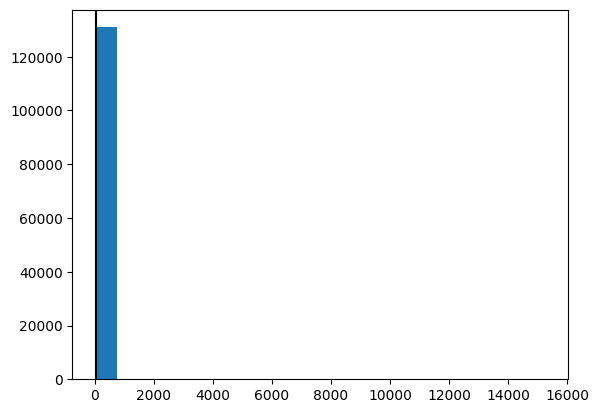

In [26]:
plt.hist(knn_detector.decision_scores_, bins=20)
plt.axvline(np.min(knn_detector.decision_scores_[np.where(outliers==1)]), c='k')
plt.show()

In [27]:
palette = 'dark'  # 'deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind'

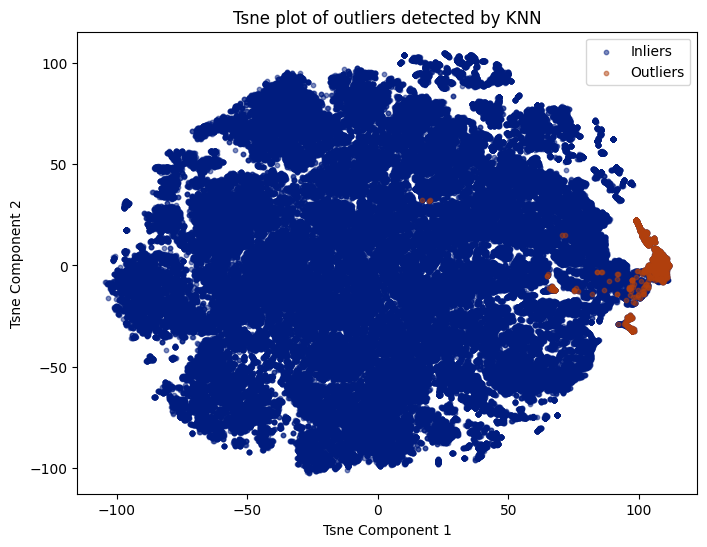

In [ ]:
# TSNE plot
plt.figure(figsize=(8, 6))

# Plot inliers
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], label='Inliers', color=sns.color_palette(palette)[0], alpha=0.5, s=10)

# Plot outliers
plt.scatter(X_tsne[outlier_knn, 0], X_tsne[outlier_knn, 1], label='Outliers', color=sns.color_palette(palette)[1], alpha=0.5, s=10)

plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.legend()
plt.title('Outlier Detection (pyod KNN) visualized on TSNE')
plt.show()


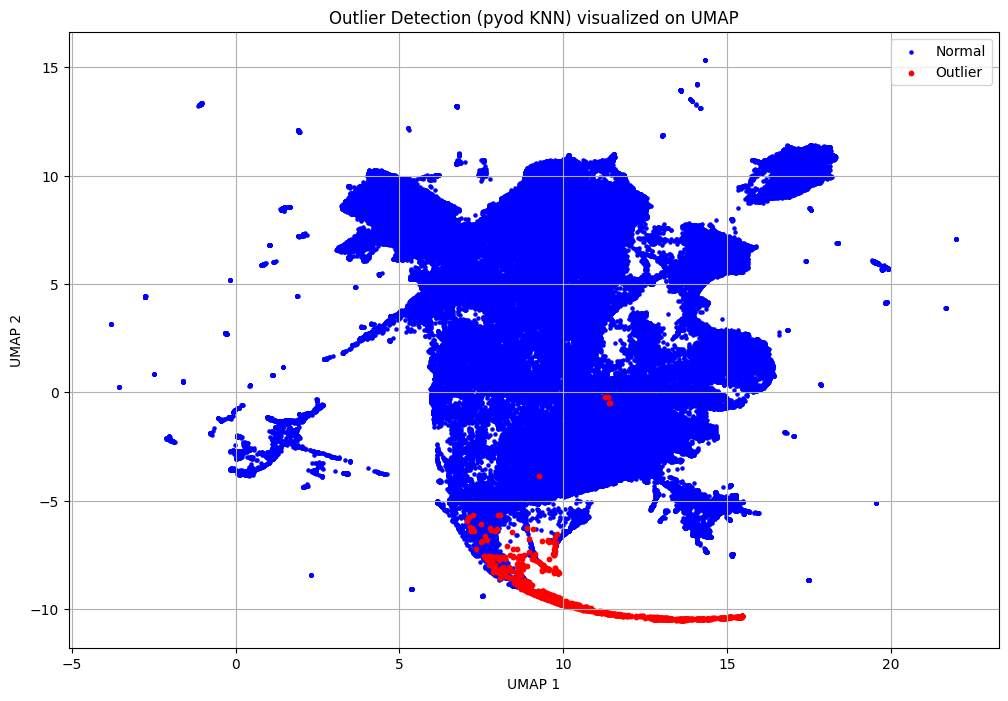

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(X_umap[outliers == 0, 0], X_umap[outliers == 0, 1], 
            color='blue', s=5, label='Inlier')

plt.scatter(X_umap[outliers == 1, 0], X_umap[outliers == 1, 1], 
            color='red', s=10, label='Outlier')

plt.title('Outlier Detection (pyod KNN) visualized on UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.show()


# ANGLE BASED-APPROACH

In [34]:
abod_detector = ABOD(contamination=0.01, n_neighbors= 50, method='fast')
abod_detector.fit(X)

ABOD(contamination=0.01, method='fast', n_neighbors=50)

In [37]:

# Save the model
joblib.dump(abod_detector, 'models/abod_model.joblib')


['models/abod_model.joblib']

In [ ]:
#abod_detector = joblib.load('models/abod_model.joblib')

In [ ]:
"""outliers = abod_detector.predict(X)
np.unique(outliers, return_counts=True)"""

KeyboardInterrupt: 

In [39]:
outliers = abod_detector.labels_  # 0 = normale, 1 = outlier
scores = abod_detector.decision_scores_  # punteggio di anomalia continuo


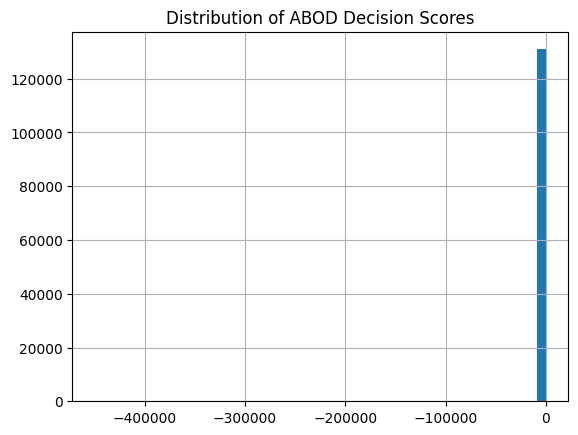

In [40]:
plt.hist(scores, bins=50)
plt.title('Distribution of ABOD Decision Scores')
plt.grid(True)
plt.show()

In [ ]:
np.save('arrays/abod_model_prediction.npy', outliers)

In [ ]:
outliers = np.load('Output_Saved/abod_model_prediction.npy')

In [42]:
outliers_abod = abod_detector.labels_  # array 0/1
outlier_abod_indices = np.where(outliers_abod == 1)[0]

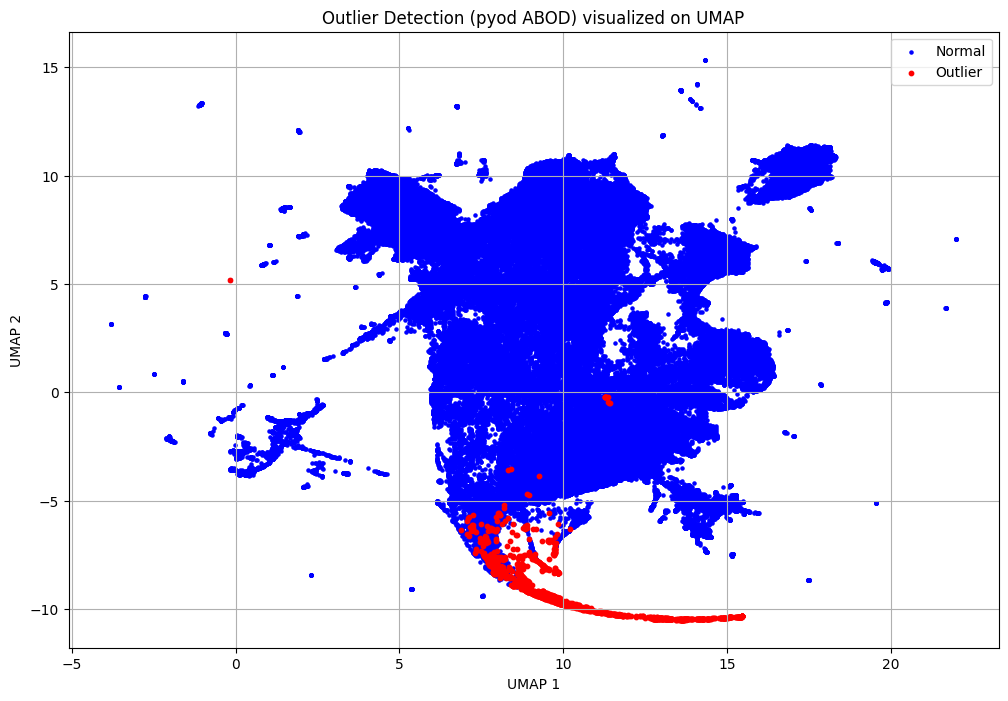

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(X_umap[abod_detector.labels_ == 0, 0], X_umap[abod_detector.labels_ == 0, 1], 
            color='blue', s=5, label='Inlier')

# Disegna i punti anomali
plt.scatter(X_umap[abod_detector.labels_ == 1, 0], X_umap[abod_detector.labels_ == 1, 1], 
            color='red', s=10, label='Outlier')

plt.title('Outlier Detection (pyod ABOD) visualized on UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.show()


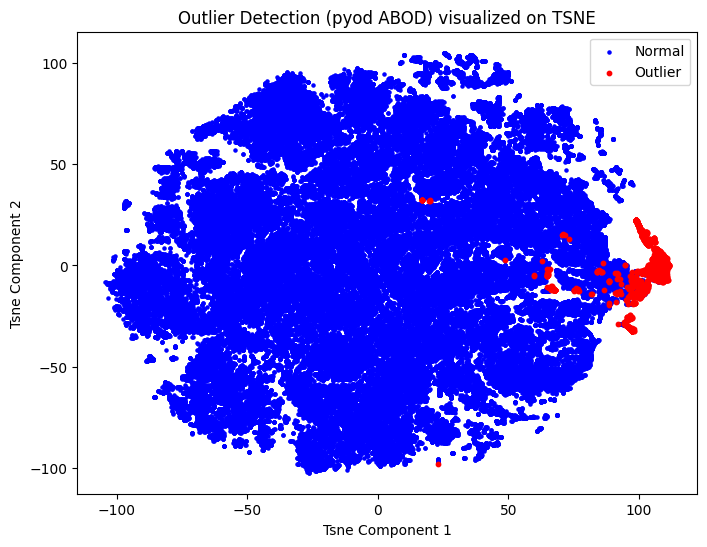

In [ ]:
# TSNE plot
plt.figure(figsize=(8, 6))

plt.scatter(X_tsne[abod_detector.labels_ == 0, 0], X_tsne[abod_detector.labels_ == 0, 1], 
            color='blue', s=5, label='Normal')

plt.scatter(X_tsne[abod_detector.labels_ == 1, 0], X_tsne[abod_detector.labels_ == 1, 1], 
            color='red', s=10, label='Outlier')

plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.legend()
plt.title('Outlier Detection (pyod ABOD) visualized on TSNE')
plt.show()


# DENSITY BASED-APPROACH

In [48]:
lof_detector = LOF(n_neighbors=10, contamination=0.01)
lof_detector.fit(X)

LOF(algorithm='auto', contamination=0.01, leaf_size=30, metric='minkowski',
  metric_params=None, n_jobs=1, n_neighbors=10, novelty=True, p=2)

In [49]:
outliers = lof_detector.labels_  # 0 = normale, 1 = outlier
scores = lof_detector.decision_scores_  # punteggio di anomalia continuo


In [52]:
outliers_lof = lof_detector.labels_  # array 0/1
outlier_lof_indices = np.where(outliers_lof == 1)[0]

In [ ]:
np.unique(outliers, return_counts=True)

In [ ]:
outlier_lof = np.where(outliers == 1)[0]

In [ ]:
plt.hist(clf.decision_scores_, bins=10)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers==1)]), c='k')
plt.show()

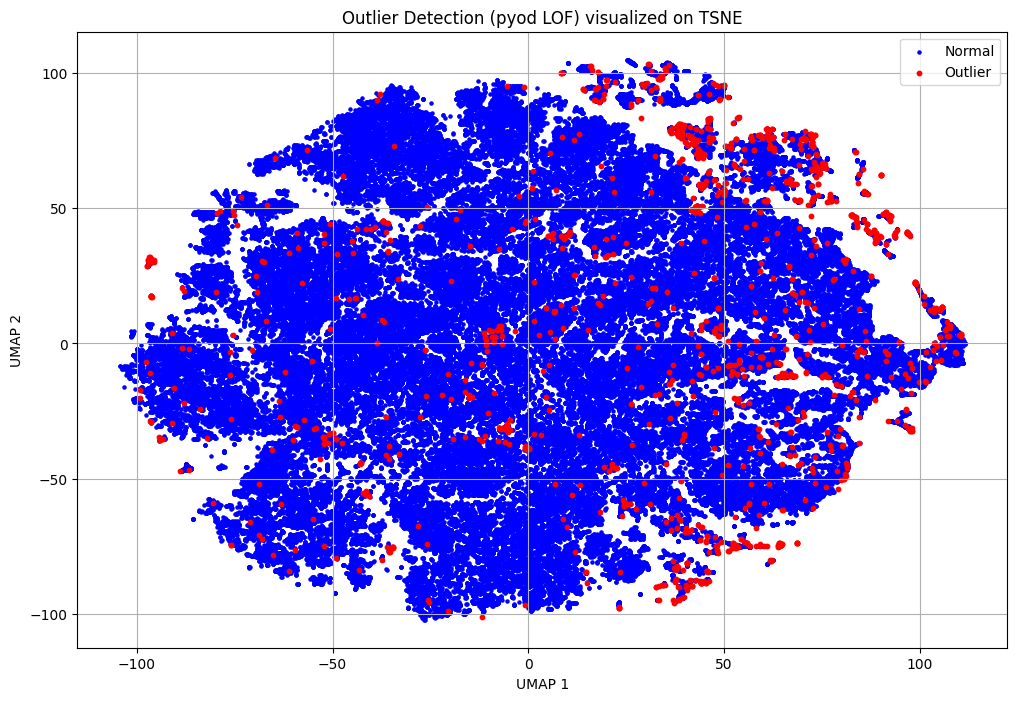

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(X_tsne[lof_detector.labels_ == 0, 0], X_tsne[lof_detector.labels_ == 0, 1], 
            color='blue', s=5, label='Inlier')

plt.scatter(X_tsne[lof_detector.labels_ == 1, 0], X_tsne[lof_detector.labels_ == 1, 1], 
            color='red', s=10, label='Outlier')

plt.title('Outlier Detection (pyod LOF) visualized on TSNE')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend()
plt.grid(True)
plt.show()


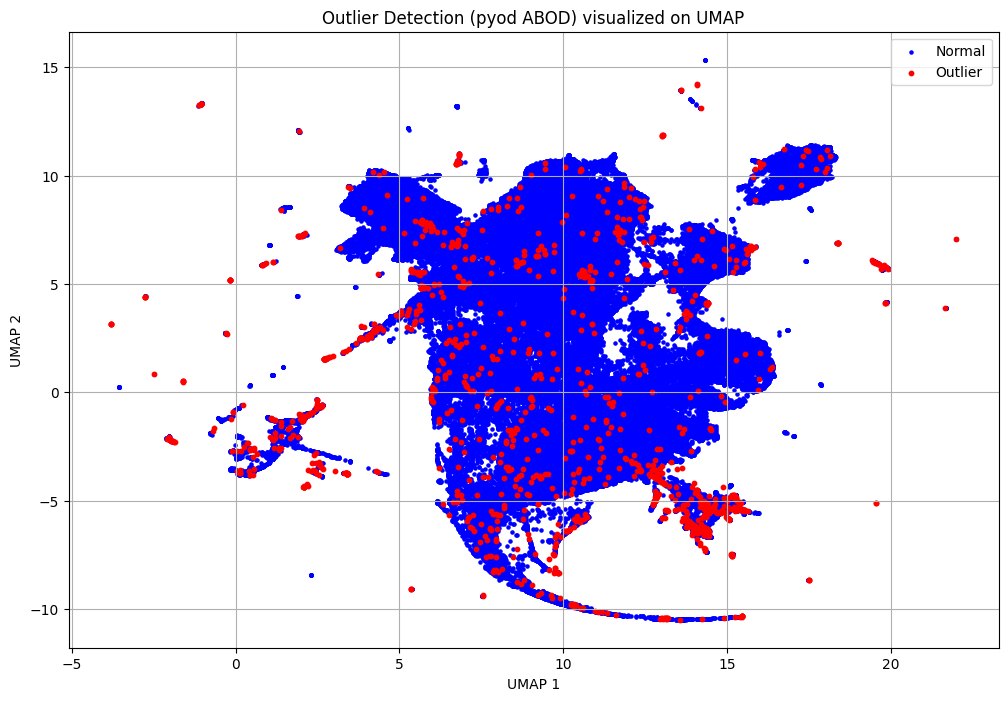

In [ ]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(X_umap[lof_detector.labels_ == 0, 0], X_umap[lof_detector.labels_ == 0, 1], 
            color='blue', s=5, label='Normal')

# Disegna i punti anomali
plt.scatter(X_umap[lof_detector.labels_ == 1, 0], X_umap[lof_detector.labels_ == 1, 1], 
            color='red', s=10, label='Outlier')

plt.title('Outlier Detection (pyod LOF) visualized on UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.show()


# ISOFOREST

In [55]:
isoforest_detector = IsolationForest(contamination=0.01)
isoforest_detector.fit(X)

IsolationForest(contamination=0.01)

In [58]:
outliers = isoforest_detector.predict(X)
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([  1310, 129664]))

In [ ]:
outlier_if = np.where(outliers == -1)[0]
print(len(outlier_if))


1310


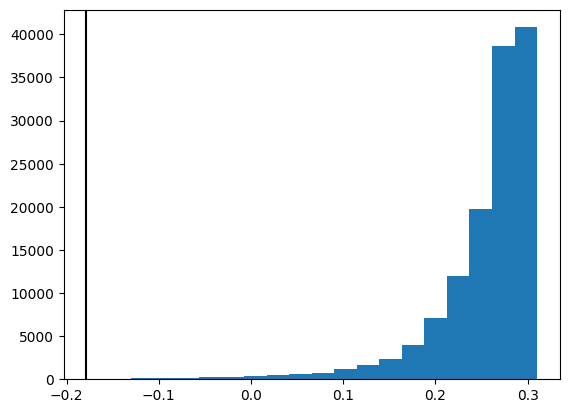

In [61]:
plt.hist(isoforest_detector.decision_function(X), bins=20)
plt.axvline(np.min(isoforest_detector.decision_function(X)[np.where(outliers== -1)]), c='k')
plt.show()

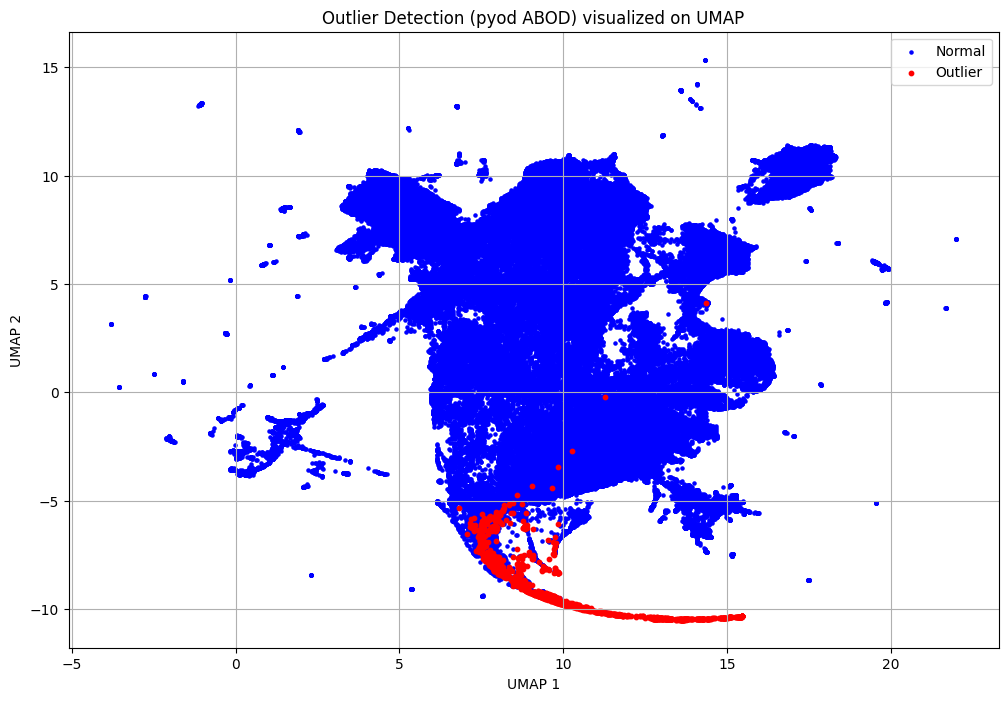

In [ ]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(X_umap[:, 0], X_umap[:, 1], 
            color='blue', s=5, label='Normal')

# Disegna i punti anomali
plt.scatter(X_umap[outlier_if, 0], X_umap[outlier_if, 1], 
            color='red', s=10, label='Outlier')

plt.title('Outlier Detection (pyod ISOFOREST) visualized on UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.show()

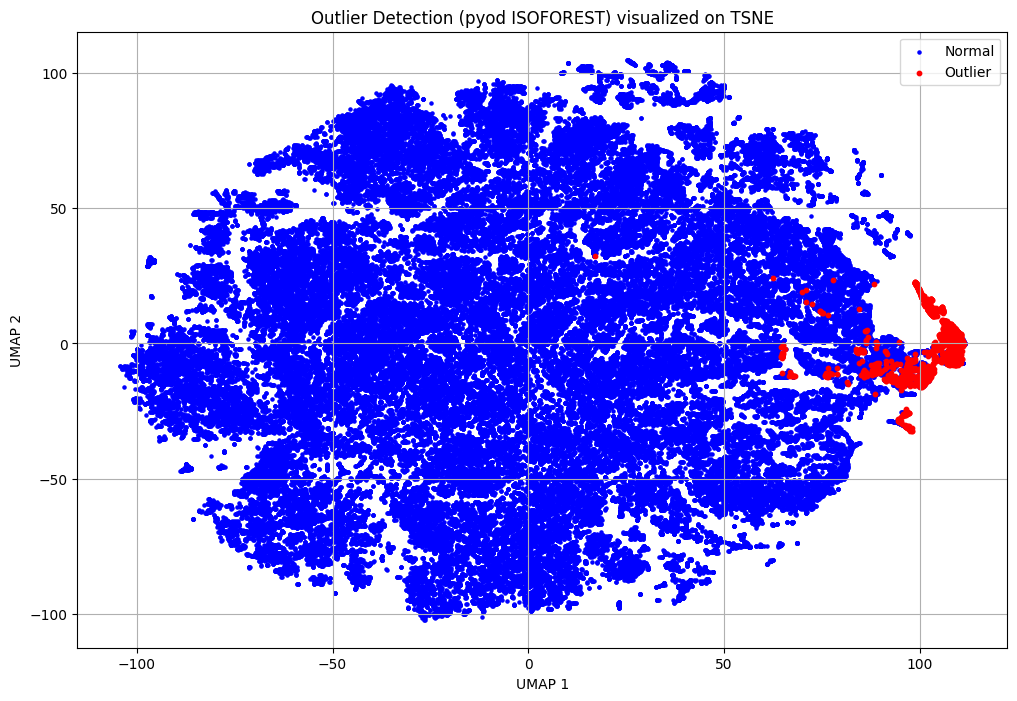

In [85]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
            color='blue', s=5, label='Normal')

# Disegna i punti anomali
plt.scatter(X_tsne[outlier_if, 0], X_tsne[outlier_if, 1], 
            color='red', s=10, label='Outlier')

plt.title('Outlier Detection (pyod ISOFOREST) visualized on TSNE')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.show()

# SUM UP

In [ ]:
# intesection (KNN + ABOD + LOF + Isolation Forest)
outliers_common_all = np.intersect1d(
    np.intersect1d(
        np.intersect1d(outlier_knn_indices, outlier_abod_indices),
        outlier_lof_indices
    ),
    outlier_if
)

# pairs interesection 
knn_abod = np.intersect1d(outlier_knn_indices, outlier_abod_indices)
knn_lof = np.intersect1d(outlier_knn_indices, outlier_lof_indices)
knn_if = np.intersect1d(outlier_knn_indices, outlier_if)
abod_lof = np.intersect1d(outlier_abod_indices, outlier_lof_indices)
abod_if = np.intersect1d(outlier_abod_indices, outlier_if)
lof_if = np.intersect1d(outlier_lof_indices, outlier_if)

# unique outliers by each method
only_knn = np.setdiff1d(outlier_knn_indices, np.union1d(np.union1d(outlier_abod_indices, outlier_lof_indices), outlier_if))
only_abod = np.setdiff1d(outlier_abod_indices, np.union1d(np.union1d(outlier_knn_indices, outlier_lof_indices), outlier_if))
only_lof = np.setdiff1d(outlier_lof_indices, np.union1d(np.union1d(outlier_knn_indices, outlier_abod_indices), outlier_if))
only_if = np.setdiff1d(outlier_if, np.union1d(np.union1d(outlier_knn_indices, outlier_abod_indices), outlier_lof_indices))

# --- STAMPA RISULTATI ---

print(f"🔵 Common outliers between the 4 methods (KNN, ABOD, LOF, Isolation Forest): {len(outliers_common_all)}")
print(f"🟠 Common outliers KNN-ABOD: {len(knn_abod)}")
print(f"🟠 Common outliers KNN-LOF: {len(knn_lof)}")
print(f"🟠 Common outliers KNN-IF: {len(knn_if)}")
print(f"🟠 Common outliers ABOD-LOF: {len(abod_lof)}")
print(f"🟠 Common outliers ABOD-IF: {len(abod_if)}")
print(f"🟠 Common outliers LOF-IF: {len(lof_if)}")

print(f"🔴 Unique outliers found only by KNN: {len(only_knn)}")
print(f"🔴 Unique outliers found only by ABOD: {len(only_abod)}")
print(f"🔴 Unique outliers found only by LOF: {len(only_lof)}")
print(f"🔴 Unique outliers found only by Isolation Forest: {len(only_if)}")



🔵 Outlier comuni a tutti e 4 i metodi (KNN, ABOD, LOF, Isolation Forest): 85
🟠 Outlier comuni KNN-ABOD: 1259
🟠 Outlier comuni KNN-LOF: 115
🟠 Outlier comuni KNN-IF: 1007
🟠 Outlier comuni ABOD-LOF: 113
🟠 Outlier comuni ABOD-IF: 1010
🟠 Outlier comuni LOF-IF: 92
🔴 Outlier unici trovati SOLO da KNN: 28
🔴 Outlier unici trovati SOLO da ABOD: 28
🔴 Outlier unici trovati SOLO da LOF: 1188
🔴 Outlier unici trovati SOLO da Isolation Forest: 274


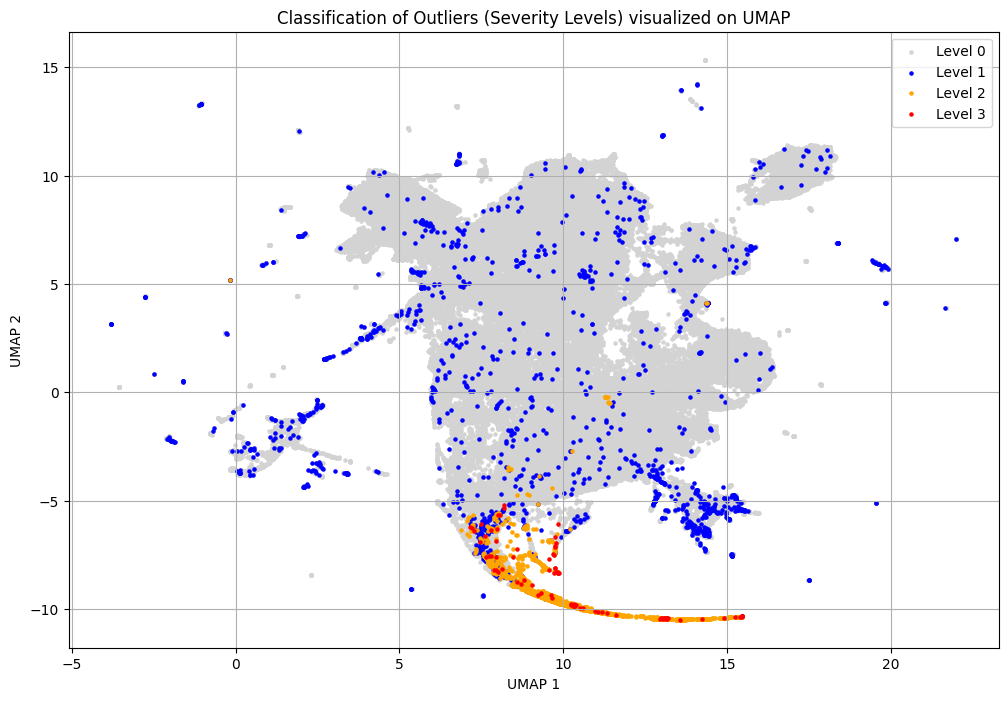

In [ ]:

n_samples = X.shape[0]  

outlier_level = np.zeros(n_samples)

# Hard Outliers (4 up)
outlier_level[outliers_common_all] = 3

# Moderate Outliers ( 2 or 3 methos)
# (every intersection 2 by 2, without the 4 ones)
moderate_outliers = np.unique(np.concatenate((
    knn_abod, knn_lof, knn_if, abod_lof, abod_if, lof_if
)))

# remove hard ones
moderate_outliers = np.setdiff1d(moderate_outliers, outliers_common_all)

outlier_level[moderate_outliers] = 2

# Weak Outliers (found only by 1 method)
weak_outliers = np.unique(np.concatenate((only_knn, only_abod, only_lof, only_if)))
outlier_level[weak_outliers] = 1

# Normal stays to 0

# 3. visualize on UMAP
plt.figure(figsize=(12, 8))

# Palette colori: 0 = grigio, 1 = blu, 2 = arancione, 3 = rosso
colors = {
    0: 'lightgray',
    1: 'blue',
    2: 'orange',
    3: 'red'
}

for level in [0, 1, 2, 3]:
    mask = (outlier_level == level)
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                color=colors[level], s=5, label=f"Level {level}")

plt.title('Classification of Outliers (Severity Levels) visualized on UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(True)
plt.show()


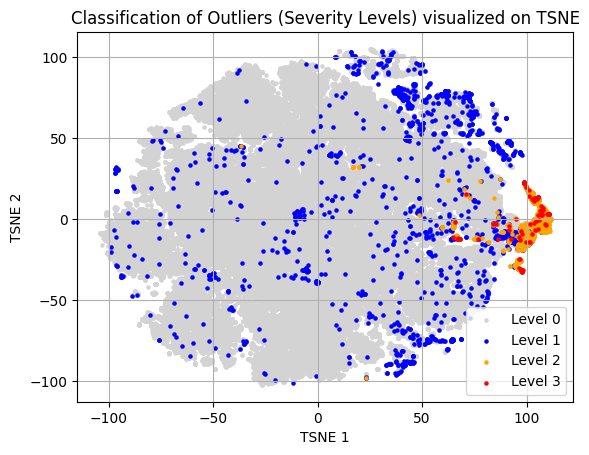

In [86]:
for level in [0, 1, 2, 3]:
    mask = (outlier_level == level)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                color=colors[level], s=5, label=f"Level {level}")

plt.title('Classification of Outliers (Severity Levels) visualized on TSNE')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_outlier_info = pd.DataFrame({
    'UMAP_1': X_umap[:, 0],
    'UMAP_2': X_umap[:, 1],
    'Outlier_Level': outlier_level.astype(int)
})

# Salva
df_outlier_info.to_csv('dataset/outlier_levels_umap.csv', index=False)


In [ ]:
mask_keep = (outlier_level == 0) | (outlier_level == 1)

df_cleaned = df[mask_keep].reset_index(drop=True)

print(f"Cleaned dataset shape: {df_cleaned.shape}")


Dimensione del dataset pulito: (129663, 69)


In [78]:
df_num_cleaned = df_cleaned.drop(cat, axis=1)

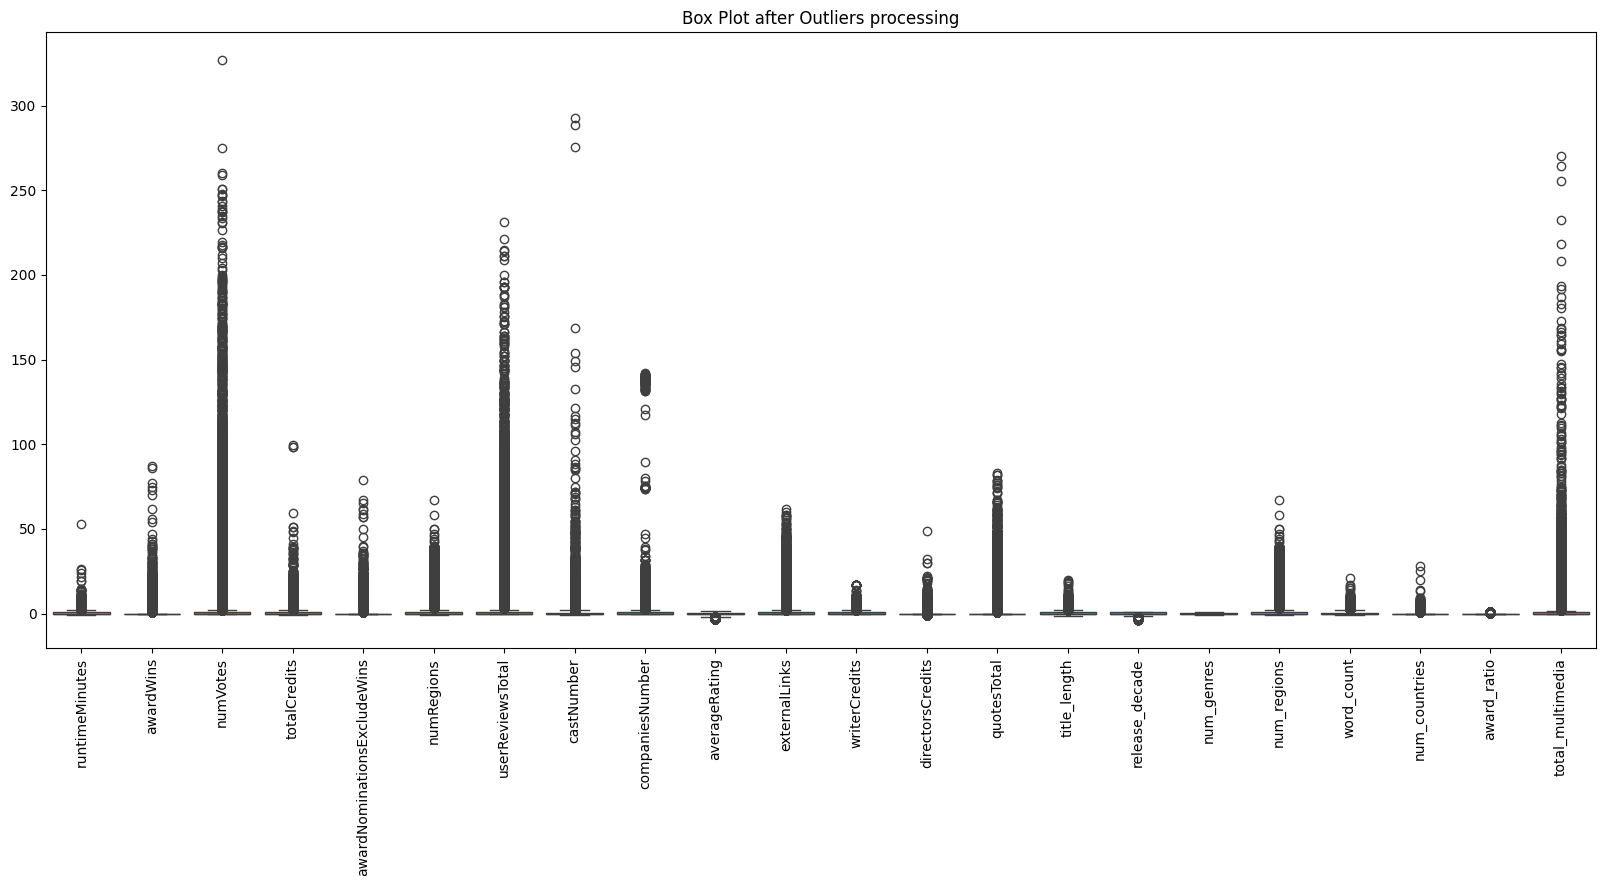

In [81]:
plt.figure(figsize=(20,8))
sns.boxplot(df_num_cleaned)
plt.xticks(rotation=90)
plt.title("Box Plot after Outliers processing")
plt.show()

In [82]:
df_cleaned.to_csv("dataset/train_post_outlier.csv")